In [3]:
import torch
import numpy as np
import matplotlib.pyplot as plt

from src.core.data.sounding_out_chorus import SoundingOutChorus
from src.core.transforms.log_mel_spectrogram import LogMelSpectrogram
from src.core.transforms.translation import translation

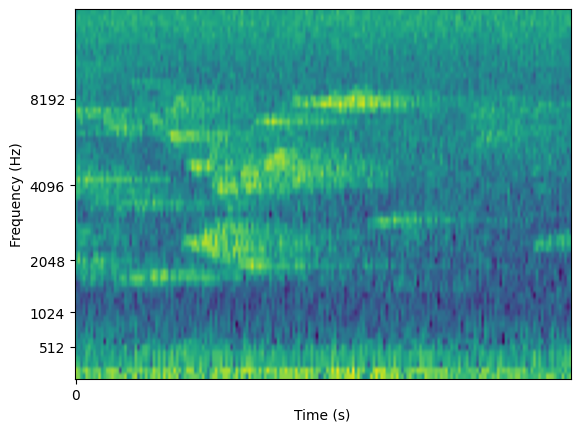

In [4]:
data = SoundingOutChorus(root="~/data/sounding_out")
mel = LogMelSpectrogram()
spec = mel(data[0][0].unsqueeze(0)).squeeze()
frame = spec[:192, :]
mel.plot(frame.t())
plt.show()

tensor([0.1738])


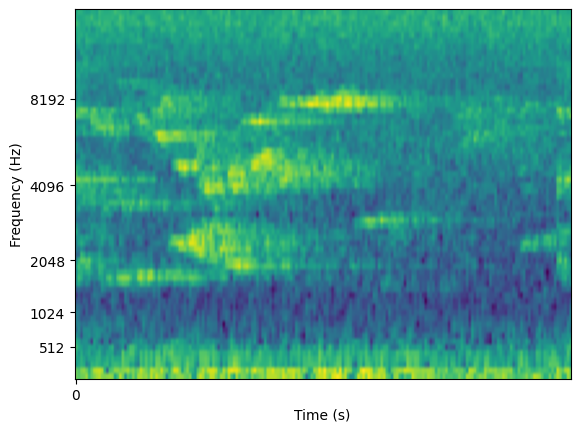

tensor([3.0307])
tensor([0.9647])


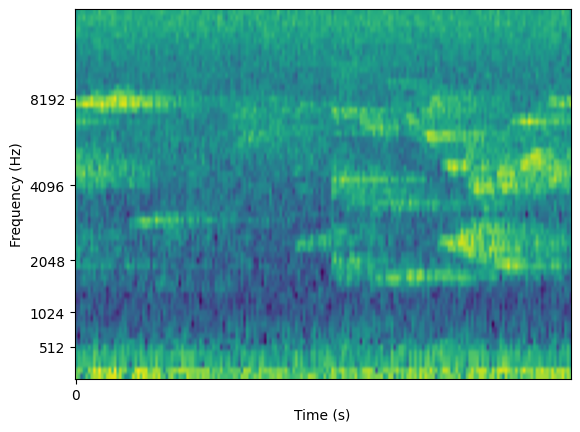

In [5]:
w2 = 1.0
# dx, dy = torch.zeros(1), torch.ones(1)
dx, dy = torch.rand(1) * 2 - 1, (torch.rand(1) * 2 - 1)
norm = torch.sqrt(dx.pow(2) + dy.pow(2) + 1e-8)
dx /= norm
dy /= norm
print(dy * torch.pi / 2)
frame_trans = translation(frame.t().view(1, 1, 64, 192), dy / 2, mode="bilinear").squeeze().t()
mel.plot(frame_trans.t())
plt.show()

theta = torch.atan2(dy, dx)
print(theta)
delta = theta / torch.pi
print(delta)
frame_trans = translation(frame.t().view(1, 1, 64, 192), delta, mode="bilinear").squeeze().t()
mel.plot(frame_trans.t())
plt.show()

0.9999999900000002
tensor([[ 1.7116],
        [-1.3590],
        [ 0.7242],
        [ 1.3776],
        [ 1.9377],
        [-0.4018]])


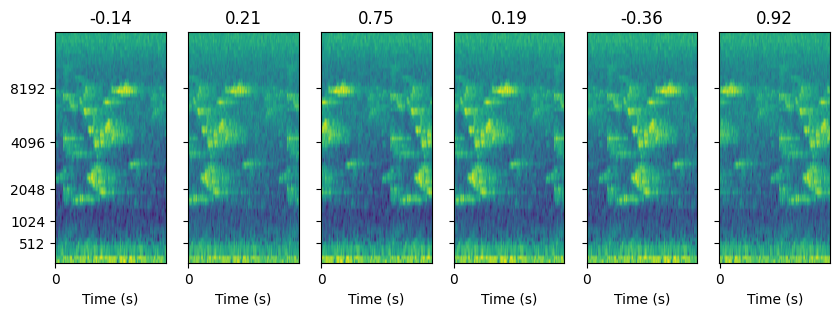

In [8]:
def sample_delta(shape, sigma: int | None = None):
    kappa = 1 / (sigma**2 + 1e-8)
    print(kappa)
    theta = torch.distributions.VonMises(
        loc=torch.pi/2 * torch.ones(shape),
        concentration=torch.ones(shape) * kappa
    ).sample()
    print(theta)
    dx, dy = torch.sin(theta), torch.cos(theta)
    return dy # theta / torch.pi

bs = 6
dy = sample_delta((bs, 1), 1)
fig, axes = plt.subplots(ncols=bs, figsize=(10, 3), sharey=True)
for i in range(bs):
    frame_trans = translation(frame.t().view(1, 1, 64, 192), dy[i], mode="bilinear").squeeze().t()
    mel.plot(frame_trans.t(), ax=axes[i])
    axes[i].set_ylabel("")
    axes[i].set_title(np.format_float_positional(dy[i].item(), 2))
plt.show()

In [189]:
1 - np.cos(np.pi - np.pi)

0.0

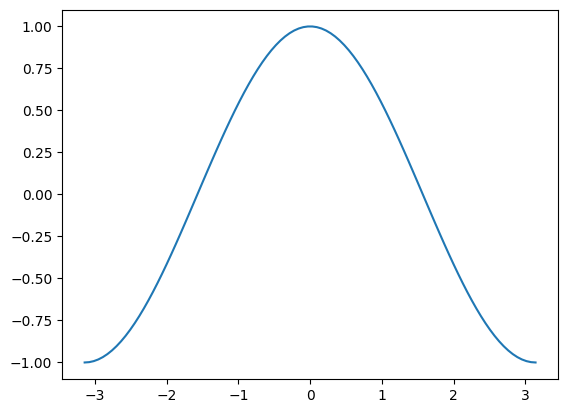

In [190]:
theta = np.linspace(-np.pi, np.pi, 100)
plt.plot(theta, np.cos(theta))